# P14a — ZORC RAG: P-body Literature Knowledge Base

**Project:** ZORC (Zip-code Of RNAs that Condense)  
**Phase:** P14a — ChromaDB + LangChain RAG  
**Lab:** MoschouLab / IMBB-FORTH / ERC PLANTEX  

This notebook demonstrates the P-body literature RAG system built with:
- **10 PDFs** from `data/papers/` (231 pages → 1244 chunks)
- **Embeddings:** `sentence-transformers/all-MiniLM-L6-v2` (local, no API key)
- **Vector store:** ChromaDB persisted at `agent/chroma_db/`
- **Retrieval:** cosine similarity search, top-k chunks

Run `python agent/ingest.py` before this notebook if `chroma_db/` does not exist.

In [1]:
import sys
from pathlib import Path

# Add project root to path so agent package is importable
project_root = Path.cwd().parent if Path.cwd().name == 'agent' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from agent.rag_query import query_literature
print('RAG system loaded successfully')

RAG system loaded successfully


## Corpus overview

In [2]:
import json

manifest_path = project_root / 'agent' / 'ingest_manifest.json'
with open(manifest_path) as fh:
    manifest = json.load(fh)

print(f"Total chunks indexed : {manifest['total_chunks']}")
print(f"Embedding model      : {manifest['embed_model']}")
print(f"Chunk size           : {manifest['chunk_size']} chars  (overlap={manifest['chunk_overlap']})")
print(f"ChromaDB collection  : {manifest['collection']}")
print()
print('Chunks per source:')
for src, n in sorted(manifest['sources'].items(), key=lambda x: -x[1]):
    print(f'  {n:4d}  {src}')

Total chunks indexed : 1244
Embedding model      : sentence-transformers/all-MiniLM-L6-v2
Chunk size           : 1000 chars  (overlap=200)
ChromaDB collection  : pbody_literature

Chunks per source:
   223  journal.pbio.3002305.pdf
   193  2025_PLANT-COMMUNICATIONS-D-25-01149_MANUSCRIPT_FILE_REV1_FINAL.pdf
   175  TPC_paper.pdf
   159  embj.2022111885.pdf
   138  1-s2.0-S0006349525034472-main.pdf
   130  koad127.pdf
    98  Bio-protocol5587.pdf
    80  1-s2.0-S1360138523001322-main.pdf
    34  erac497.pdf
    14  s41422-025-01133-4.pdf


---
## Query 1 — RNA features predicting P-body enrichment

In [3]:
Q1 = 'What RNA features predict P-body enrichment?'
results_q1 = query_literature(Q1, k=5)

print(f'Query: {Q1}\n')
for r in results_q1:
    print(f"[{r['rank']}] {r['source']}  |  page {r['page']+1}  |  score={r['score']:.4f}")
    print(r['text'][:400])
    print()

/home/moschou/miniconda3/envs/zorc_pipeline/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9783.57it/s]

Query: What RNA features predict P-body enrichment?

[1] TPC_paper.pdf  |  page 23  |  score=0.4566
Supplemental Figure S16 . Effect of ACC on SCAR/ 
WAVE-DCP1 axis and PBs.
Supplemental Table S1 . Primer lists.
Supplemental Data Set 1 . RBPs enriched in T-RIP under 
NS or HS.
Supplemental Data Set 2 . RNAs enriched/depleted from 
T-RIP.
Supplemental Data Set 3 . RNA and GO terms enriched in 
T-RIP in both NS and HS (519 genes).
Supplemental Data Set 4 . RT-qPCR RNAs used for correl -
ation with

[2] TPC_paper.pdf  |  page 5  |  score=0.4226
been previously described and is consistent with our results 
here ( Jang et al. 2019 ). We also observed common GO terms 
between NS and HS, e.g. of hormonal responses and actin 
( Fig. 2A ; indicated with magenta boxes, FDR, NS = 5.15e
−5
, 
HS = 6.04e
−5
). The PBs-depleted RNAs fit into 2 subnetworks 
related to the housekeeping processes of nucleic acid and 
metabolism (fitting to a broader m

[3] Bio-protocol5587.pdf  |  page 24  |  score=0.3

---
## Query 2 — Heat stress and P-body assembly

In [4]:
Q2 = 'How does heat stress affect P-body assembly?'
results_q2 = query_literature(Q2, k=5)

print(f'Query: {Q2}\n')
for r in results_q2:
    print(f"[{r['rank']}] {r['source']}  |  page {r['page']+1}  |  score={r['score']:.4f}")
    print(r['text'][:400])
    print()

Query: How does heat stress affect P-body assembly?

[1] koad127.pdf  |  page 3  |  score=0.1594
PB core proteins can phase separate in vitro, suggesting 
that the nucleation step might be involved in the PB biogen-
esis in vivo (Schutz et al. 2017; Luo et al. 2018). However, un-
like SGs, PBs exist at a basal level under unstressed (normal) 
conditions and are strongly induced in response to stress, 
Figure 1.Diagram of the major principles underlying biomolecular condensate formation. A cer

[2] embj.2022111885.pdf  |  page 3  |  score=0.1533
new helicase identified as a PB component (green arrow). The scale on the right shows log 2FC of protein abundance. Note that only the PB core components were
enriched in the PDL (i.e., the proxitome, log 2FC ~ 1 or above) but not in AP. Furthermore, heat stress (HS) increased the enrichment of some PB core components.
C Comparison of AP/PDL interacting networks produced from APEAL. STRING density

[3] 1-s2.0-S0006349525034472-main.pdf  |  page 

---
## Query 3 — DCP1 and mRNA decapping

In [5]:
Q3 = 'What is the role of DCP1 in mRNA decapping?'
results_q3 = query_literature(Q3, k=5)

print(f'Query: {Q3}\n')
for r in results_q3:
    print(f"[{r['rank']}] {r['source']}  |  page {r['page']+1}  |  score={r['score']:.4f}")
    print(r['text'][:400])
    print()

Query: What is the role of DCP1 in mRNA decapping?

[1] TPC_paper.pdf  |  page 13  |  score=0.5625
over. SCAR2 is the main protein responsible for retracting DCP1 from PBs and thus, their dissolution ( Liu et al. 2023 ).
RNA composition of processing bodies                                                                              THE PLANT CELL 2024: 36; 559–584 | 571
Downloaded from https://academic.oup.com/plcell/article/36/3/559/7424678 by Access provided by HEAL-Link (University of Crete

[2] TPC_paper.pdf  |  page 3  |  score=0.4850
names). The T-RIP DCP1 datasets had more enriched RNAs 
compared with GFP; only 694 RNAs were enriched in the 
T-RIP GFP datasets ( Fig. 1B , log
2
FC
DCP1/GFP 
< −1; i.e. 3.49% 
from HS + NS). At the transcriptome level, however, HS 
induced similar quantitative changes in RNA levels for 
both NS and HS for up- and downregulated genes; ca. 500 
RNAs were differentially expressed between DCP1 and 

[3] TPC_paper.pdf  |  page 12  |  score=0.4581
Figu

---
## Interactive query

Enter your own question below.

In [6]:
custom_query = 'What is the role of IDR in phase separation of P-body components?'
k = 3

results_custom = query_literature(custom_query, k=k)
print(f'Query: {custom_query}\n')
for r in results_custom:
    print(f"[{r['rank']}] {r['source']}  |  page {r['page']+1}  |  score={r['score']:.4f}")
    print(r['text'][:500])
    print()

Query: What is the role of IDR in phase separation of P-body components?

[1] koad127.pdf  |  page 3  |  score=0.3663
PB core proteins can phase separate in vitro, suggesting 
that the nucleation step might be involved in the PB biogen-
esis in vivo (Schutz et al. 2017; Luo et al. 2018). However, un-
like SGs, PBs exist at a basal level under unstressed (normal) 
conditions and are strongly induced in response to stress, 
Figure 1.Diagram of the major principles underlying biomolecular condensate formation. A certain protein concentration (dependent on various 
factors, such as temperature, redox state, pH) ena

[2] erac497.pdf  |  page 2  |  score=0.3645
interactions are enabled among intra- or intermolecular stickers (e.g. protein 1–protein 2 interaction on the cartoon). When 
reaching a system-specific threshold concentration (Cthreshold), the whole system undergoes a transition into at least two 
or more phases, a process known as phase separation. Here, the dense phases are often 

---
## Score distribution across all 3 primary queries

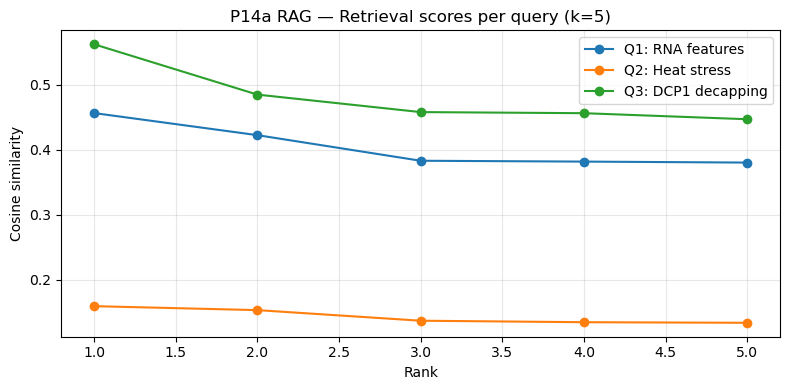

Plot saved: agent/rag_scores.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

queries = {
    'Q1: RNA features': results_q1,
    'Q2: Heat stress': results_q2,
    'Q3: DCP1 decapping': results_q3,
}

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(5) + 1
for label, hits in queries.items():
    scores = [h['score'] for h in hits]
    ax.plot(x, scores, marker='o', label=label)

ax.set_xlabel('Rank')
ax.set_ylabel('Cosine similarity')
ax.set_title('P14a RAG — Retrieval scores per query (k=5)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(project_root / 'agent' / 'rag_scores.png', dpi=120)
plt.show()
print('Plot saved: agent/rag_scores.png')

---
## Next step: P14b — LangGraph agent

The RAG module built here (`agent/rag_query.query_literature`) will be used
as the `retrieve_literature` node in the LangGraph workflow (`agent/zorc_agent.py`):

```
START → get_prediction (ZORC FastAPI) → retrieve_literature (ChromaDB) → generate_report (Claude) → END
```